In [1]:
import pandas as pd
import os
import glob

sample = 'SMC01-T'

os.makedirs(f'../../pipeline_testing/transitory_cells/{sample}', exist_ok=True) 
files = glob.glob(f'../../pipeline_testing/mellon_analysis/{sample}/*_specialists_and_generalists.csv', recursive=True)
files.sort()

arch_name = []
sg_cells = []
for file in files:
    name = os.path.basename(file)
    if (name.startswith('Archetype')==True): 
        name = name.split('_specialists')[0]
    else:
        name = 'generalists'
    arch_name.append(name)
    df = pd.read_csv(file, index_col=0)
    sg_cells.append(df)

sg_cells = pd.concat(sg_cells, axis=0)
all_cells = pd.read_csv(f"../../pipeline_testing/data/{sample}/{sample}_required_cell_modified.tsv", sep="\t")
trans_cells = all_cells.loc[~all_cells['index'].isin(sg_cells.cells),:]

In [2]:
dist_data = pd.read_csv(f"../../pipeline_testing/distance_and_ordering/{sample}/cell_distances.csv", index_col=0)
ordering = pd.read_csv(f"../../pipeline_testing/distance_and_ordering/{sample}/cell_ordering.csv", index_col=0)
ordering

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X2653,X2654,X2655,X2656,X2657,X2658,X2659,X2660,X2661,X2662
1,432,227,405,570,422,709,438,772,210,406,...,1259,1355,1256,1295,1301,1326,1383,1397,1292,1359
2,1120,1216,1240,1128,1115,1141,1228,1126,1137,1106,...,464,645,712,259,236,1069,144,790,427,503
3,1411,1265,1296,1389,1396,1284,1358,1332,1327,1392,...,309,232,570,406,509,608,269,992,1084,392
4,503,1069,144,236,767,464,203,427,522,19,...,752,392,178,406,1265,992,422,529,1152,1144
5,2448,1996,2376,1974,1994,2332,1666,2142,1472,1935,...,582,405,799,602,124,453,432,921,709,1047


In [3]:
import pandas as pd
import numpy as np

ordering_matrix = ordering.values
dists_matrix = dist_data.values
sort_indices = np.argsort(ordering_matrix, axis=1)
sorted_ids = np.take_along_axis(ordering_matrix, sort_indices, axis=1)
sorted_dists = np.take_along_axis(dists_matrix, sort_indices, axis=1)
df_ordering_final = pd.DataFrame(sorted_ids, columns=ordering.columns, index=ordering.index)
df_dists_final = pd.DataFrame(sorted_dists, columns=dist_data.columns, index=dist_data.index)

In [4]:
df_dists_final

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X2653,X2654,X2655,X2656,X2657,X2658,X2659,X2660,X2661,X2662
1,15.779640,12.908139,29.814907,30.191420,17.623831,14.296620,14.358864,23.564002,24.392696,11.271710,...,51.185225,48.485385,46.132793,49.561590,47.335453,43.471580,49.274327,47.336666,50.892589,45.075027
2,45.203635,45.881589,44.721467,44.824134,45.959372,47.396771,45.280618,43.619430,42.080750,47.753839,...,47.294396,45.522882,43.777341,46.918661,45.040125,45.832518,49.061825,44.618206,47.597475,41.513230
3,51.082831,54.652191,49.286840,45.431613,47.913904,53.438965,53.118502,44.782260,52.452811,55.248587,...,47.318582,45.491883,46.607064,47.120362,48.574954,45.132748,48.138775,44.341157,45.543165,45.487995
4,51.374821,53.225416,34.347025,35.293021,49.635030,51.787872,51.021198,43.882005,40.418615,53.993763,...,29.358280,34.983115,42.169583,33.485081,33.257737,46.455701,32.468531,33.776016,30.385976,36.188004
5,42.123837,44.318047,38.975007,39.460659,44.386186,42.557262,44.260172,42.162238,40.849159,45.638409,...,23.724620,18.985878,14.227071,19.642089,21.034567,13.545176,20.259344,21.069024,22.898907,20.762593


In [5]:
df_dists_final.columns = all_cells['index']
dist_data_trans = df_dists_final.loc[:,df_dists_final.columns.isin(trans_cells['index'])]

In [6]:
import numpy as np

dist_data_transposed = dist_data_trans.T
inv_dist = 1/dist_data_transposed
weights = inv_dist.div(inv_dist.sum(axis=1), axis=0)
weights = weights.add_prefix('Archetype_')

def check_contribution(row):   
    top_2 = row.nlargest(2)
    current_sum = top_2.sum()
    return pd.Series([f"{top_2.index[0]}_{top_2.index[1]}", round(current_sum, 4)])
    
weights[['cont', 'cont_score']] = weights.apply(check_contribution, axis=1, result_type='expand')

In [7]:
import pandas as pd

# Sort names by length (This ensures 'A3_4' is checked safely before 'A3')
sorted_names = sorted(arch_name, key=len, reverse=True)

# Create a pattern that ensures the element is made ONLY of your valid names
pattern = rf"^({ '|'.join(sorted_names) })(_({ '|'.join(sorted_names) }))*$"

weights['cont_mod'] = weights['cont'].where(
    weights['cont'].str.match(pattern), 
    pd.NA
)
weights.to_csv(f"../../pipeline_testing/transitory_cells/{sample}/{sample}_archetype_contribution_score.csv")

In [8]:
weights['cont'].value_counts()

cont
Archetype_5_Archetype_4    44
Archetype_3_Archetype_4     6
Archetype_2_Archetype_4     4
Archetype_4_Archetype_5     2
Archetype_5_Archetype_2     1
Archetype_5_Archetype_3     1
Name: count, dtype: int64

In [9]:
## We are choosing those two archetypes where at least more than 20 transitory cells are present between two archetypes. 
## This can be seen in the previous snippet
weights_mod = weights[weights['cont'].isin(['Archetype_4_Archetype_5', 'Archetype_5_Archetype_4'])]
weights_mod.shape

(46, 8)

## Pseudotime between specialists including transitory cells using palantir

In [10]:
files

['../../pipeline_testing/mellon_analysis/SMC01-T/Archetype_1_specialists_mellon_high_density_specialists_and_generalists.csv',
 '../../pipeline_testing/mellon_analysis/SMC01-T/Archetype_2_specialists_mellon_high_density_specialists_and_generalists.csv',
 '../../pipeline_testing/mellon_analysis/SMC01-T/Archetype_3_specialists_mellon_high_density_specialists_and_generalists.csv',
 '../../pipeline_testing/mellon_analysis/SMC01-T/Archetype_4_0_specialists_cluster_0_mellon_high_density_specialists_and_generalists.csv',
 '../../pipeline_testing/mellon_analysis/SMC01-T/Archetype_4_1_specialists_cluster_1_mellon_high_density_specialists_and_generalists.csv',
 '../../pipeline_testing/mellon_analysis/SMC01-T/Archetype_4_2_specialists_cluster_2_mellon_high_density_specialists_and_generalists.csv',
 '../../pipeline_testing/mellon_analysis/SMC01-T/Archetype_4_3_specialists_cluster_3_mellon_high_density_specialists_and_generalists.csv',
 '../../pipeline_testing/mellon_analysis/SMC01-T/Archetype_4_4_

In [11]:
## Chose files which are linked with that archetype number. If the transitory is between two archetypes where one or both archetypes have
## more than one clusters then consider all possible combinations and run the pseudotime trajectory analysis for all types of combinations.
p1 = pd.read_csv(files[3], index_col=0)
p2 = pd.read_csv(files[10], index_col=0)
req_cells = p1.cells.tolist() + weights_mod.index.tolist() + p2.cells.tolist()

In [12]:
len(req_cells)

790

In [13]:
## Please give a naming to this transitory analysis. This will be the name of the final destination folder where all the result from 
## pseudotime analysis will be saved
archetype = "A4_0_A5"
os.makedirs(f'../../pipeline_testing/transitory_cells/{sample}/{archetype}', exist_ok=True) 
exp_data = pd.read_csv(f"../../pipeline_testing/data/{sample}/{sample}_TPM_mod.csv", index_col=0) 
req_exp_data = exp_data.loc[:,exp_data.columns.isin(req_cells)]
req_exp_data.to_csv(f"../../pipeline_testing/transitory_cells/{sample}/{archetype}/{archetype}_heatmap.csv")

In [15]:
import anndata as ad
req_exp_data.index.name = None
adata = ad.AnnData(X=req_exp_data)
adata = adata.T
adata.obs['cells'] = adata.obs_names
all_cells.index = all_cells['index']
filt_cells = all_cells.loc[all_cells.index.isin(adata.obs.cells),:]
adata.obs['cell_type'] = filt_cells['Cell_type'].values
adata.obs.to_csv(f"../../pipeline_testing/transitory_cells/{sample}/{archetype}/cells_between_{archetype}.csv")

In [16]:
import palantir
import scanpy as sc
sc.pp.pca(adata)
dm_res = palantir.utils.run_diffusion_maps(adata, pca_key='X_pca', n_components=5)

/home/sbllab/.local/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [17]:
ms_data = palantir.utils.determine_multiscale_space(adata)

In [18]:
sc.pp.neighbors(adata)
sc.tl.umap(adata)

/home/sbllab/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


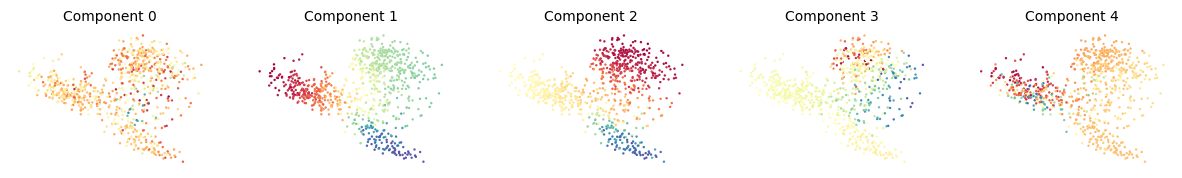

In [19]:
import matplotlib.pyplot as plt
palantir.plot.plot_diffusion_components(adata, embedding_basis='X_pca')
plt.show()

In [20]:
## Identifying start cell in an unbiased way
start_cell = dm_res['EigenVectors'].iloc[:, 0].idxmax()
start_cell

'SMC01-T_CGCTGGAGTGTTCGAT'

In [21]:
pr_res = palantir.core.run_palantir(adata, start_cell, num_waypoints=500)

Sampling and flocking waypoints...
Time for determining waypoints: 0.00017403761545817058 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.008426793416341146 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...


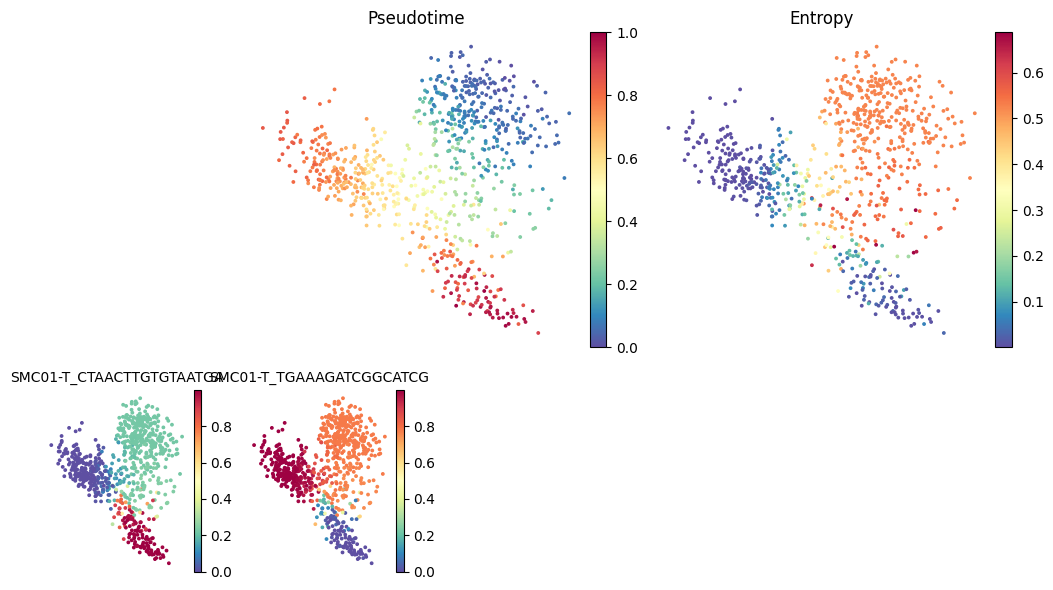

In [22]:
palantir.plot.plot_palantir_results(adata, embedding_basis='X_pca', s=3)
plt.show()

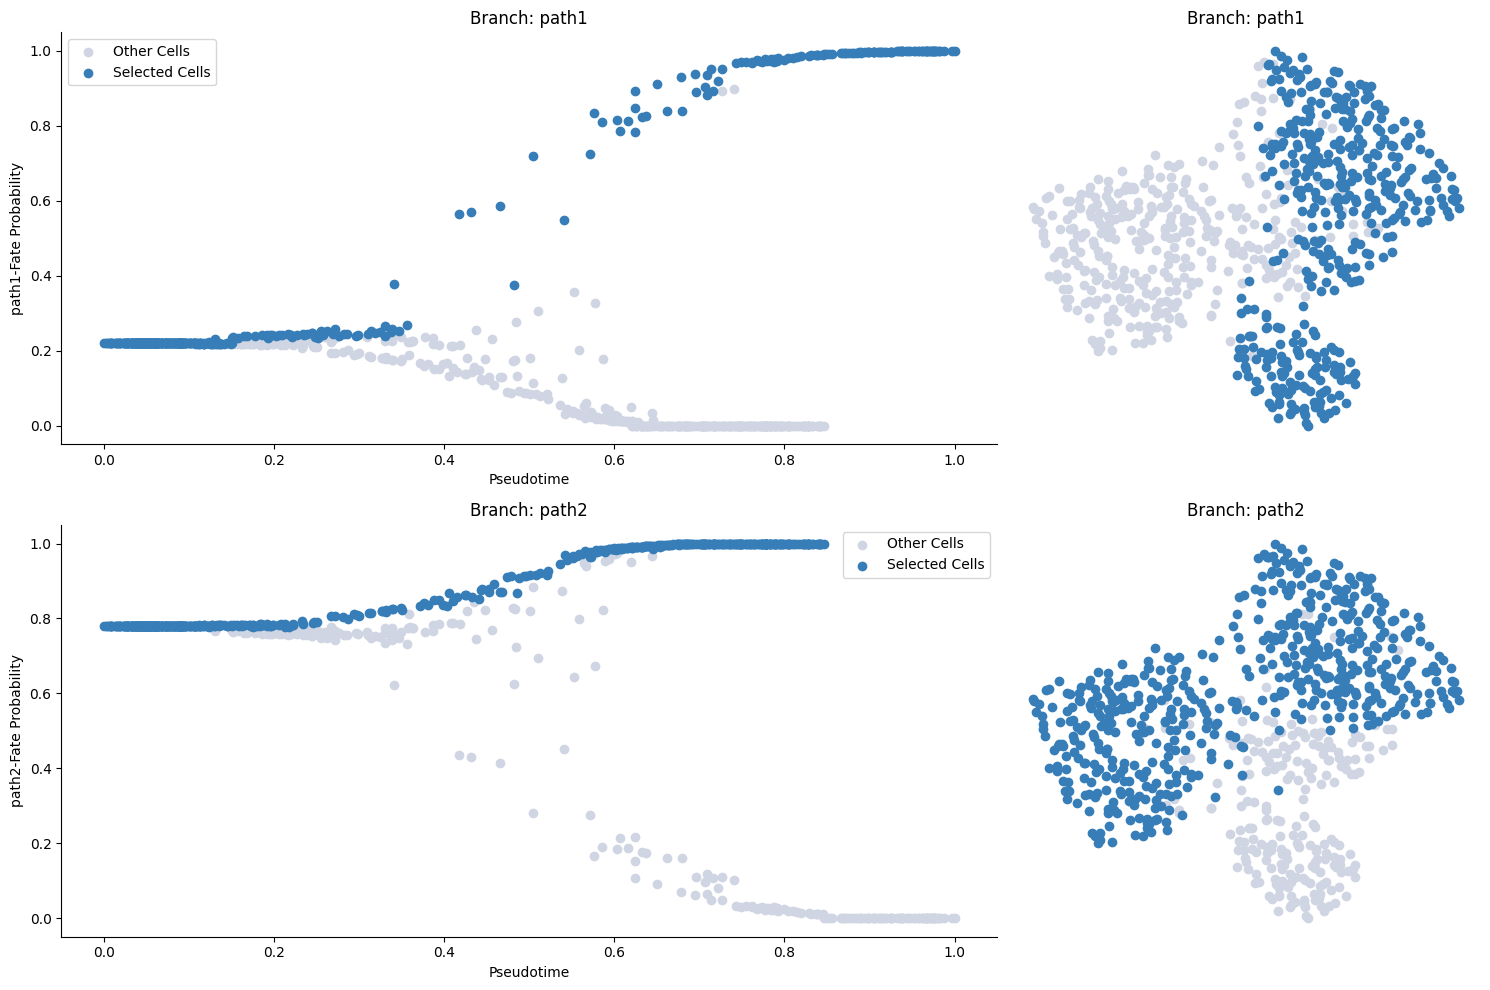

In [26]:
adata.obsm['palantir_fate_probabilities'] = adata.obsm['palantir_fate_probabilities'].set_axis(['path1', 'path2'], axis=1)
masks = palantir.presults.select_branch_cells(adata, q=.01, eps=.01)
palantir.plot.plot_branch_selection(adata, embedding_basis='X_umap')
plt.savefig(f"../../pipeline_testing/transitory_cells/{sample}/{archetype}/trajectory_paths_umap.pdf", dpi=300)
plt.show()

[2026-08-29 14:29:35,538] [INFO    ] Using sparse Gaussian Process since n_landmarks (50) < n_samples (421) and rank = 1.0.
[2026-08-29 14:29:35,540] [INFO    ] Using covariance function Matern52(ls=0.7139877080917358).
[2026-08-29 14:29:35,543] [INFO    ] Computing 50 landmarks with k-means clustering (random_state=42).
[2026-08-29 14:29:35,591] [INFO    ] Sigma interpreted as element-wise standard deviation.
[2026-08-29 14:29:35,681] [INFO    ] Using sparse Gaussian Process since n_landmarks (50) < n_samples (564) and rank = 1.0.
[2026-08-29 14:29:35,683] [INFO    ] Using covariance function Matern52(ls=0.7139877080917358).
[2026-08-29 14:29:35,684] [INFO    ] Computing 50 landmarks with k-means clustering (random_state=42).
[2026-08-29 14:29:35,730] [INFO    ] Sigma interpreted as element-wise standard deviation.


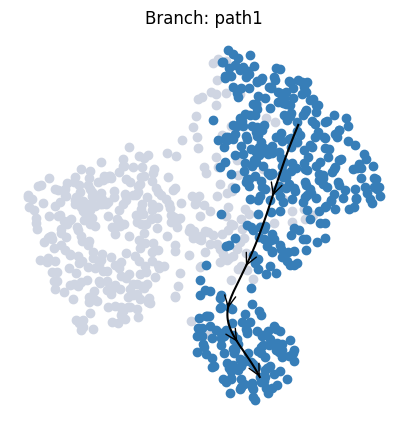

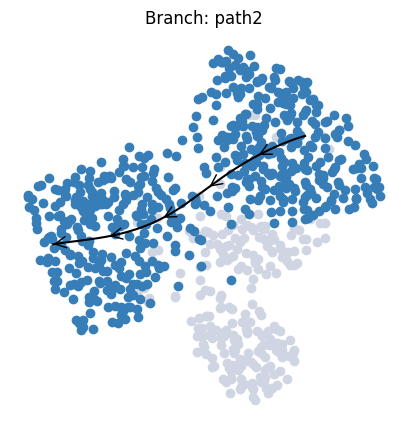

In [27]:
palantir.plot.plot_trajectory(adata, 'path1', embedding_basis='X_umap')
plt.savefig(f"../../pipeline_testing/transitory_cells/{sample}/{archetype}/path1_traj_umap.pdf", dpi=300)

palantir.plot.plot_trajectory(adata, "path2", embedding_basis='X_umap')
plt.savefig(f"../../pipeline_testing/transitory_cells/{sample}/{archetype}/path2_traj_umap.pdf", dpi=300)

# palantir.plot.plot_trajectory(adata, "path3", embedding_basis='X_umap')
# plt.savefig(f"../../pipeline_testing/transitory_cells/{sample}/path3_traj_umap.pdf", dpi=300)

# palantir.plot.plot_trajectory(adata, "path4", embedding_basis='X_umap')
# plt.savefig(f"../../pipeline_testing/transitory_cells/{sample}/path4_traj_umap.pdf", dpi=300)

[2026-08-29 14:29:58,509] [INFO    ] Using sparse Gaussian Process since n_landmarks (50) < n_samples (421) and rank = 1.0.
[2026-08-29 14:29:58,511] [INFO    ] Using covariance function Matern52(ls=0.7139877080917358).
[2026-08-29 14:29:58,513] [INFO    ] Computing 50 landmarks with k-means clustering (random_state=42).
[2026-08-29 14:29:58,549] [INFO    ] Sigma interpreted as element-wise standard deviation.
[2026-08-29 14:29:59,055] [INFO    ] Using sparse Gaussian Process since n_landmarks (50) < n_samples (564) and rank = 1.0.
[2026-08-29 14:29:59,056] [INFO    ] Using covariance function Matern52(ls=0.7139877080917358).
[2026-08-29 14:29:59,058] [INFO    ] Computing 50 landmarks with k-means clustering (random_state=42).
[2026-08-29 14:29:59,082] [INFO    ] Sigma interpreted as element-wise standard deviation.


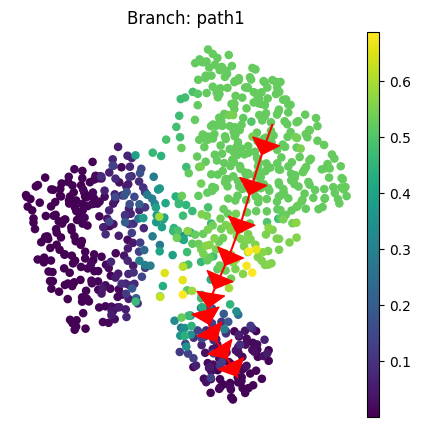

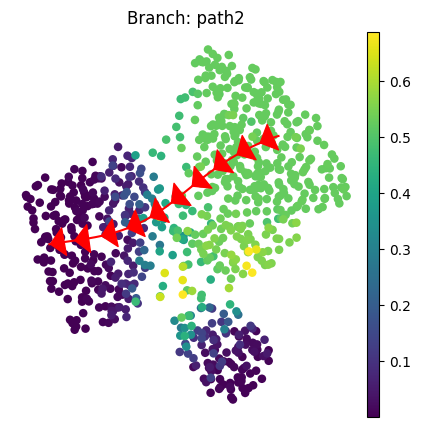

In [28]:
palantir.plot.plot_trajectory(
    adata,
    branch = "path1",
    embedding_basis='X_umap',
    cell_color="palantir_entropy",
    n_arrows=10,
    color="red",
    scanpy_kwargs=dict(cmap="viridis"),
    arrowprops=dict(arrowstyle="-|>,head_length=.5,head_width=.5"),
)
plt.savefig(f"../../pipeline_testing/transitory_cells/{sample}/{archetype}/path1_entropy_traj_umap.pdf", dpi=300)

palantir.plot.plot_trajectory(
    adata,
    branch = "path2",
    embedding_basis='X_umap',
    cell_color="palantir_entropy",
    n_arrows=10,  
    color="red",
    scanpy_kwargs=dict(cmap="viridis"),
    arrowprops=dict(arrowstyle="-|>,head_length=.5,head_width=.5"),
)
plt.savefig(f"../../pipeline_testing/transitory_cells/{sample}/{archetype}/path2_entropy_traj_umap.pdf", dpi=300)

# palantir.plot.plot_trajectory(
#     adata,
#     branch = "path3",
#     embedding_basis='X_umap',
#     cell_color="palantir_entropy",
#     n_arrows=10,
#     color="red",
#     scanpy_kwargs=dict(cmap="viridis"),
#     arrowprops=dict(arrowstyle="-|>,head_length=.5,head_width=.5"),
# )
# plt.savefig(f"../../pipeline_testing/transitory_cells/{sample}/path3_entropy_traj_umap.pdf", dpi=300)

# palantir.plot.plot_trajectory(
#     adata,
#     branch = "path4",
#     embedding_basis='X_umap',
#     cell_color="palantir_entropy",
#     n_arrows=10,
#     color="red",
#     scanpy_kwargs=dict(cmap="viridis"),
#     arrowprops=dict(arrowstyle="-|>,head_length=.5,head_width=.5"),
# )
# plt.savefig(f"../../pipeline_testing/transitory_cells/{sample}/path4_entropy_traj_umap.pdf", dpi=300)

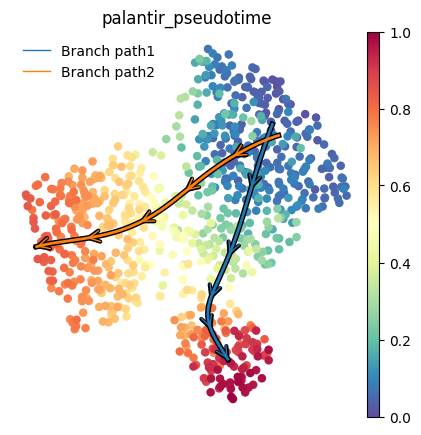

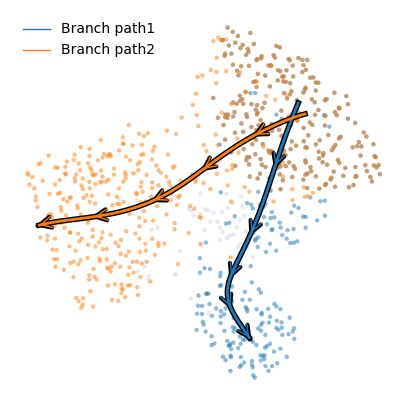

In [29]:
palantir.plot.plot_trajectories(adata, pseudotime_interval=(0, .9), embedding_basis='X_umap')
# When using cell_color="branch_selection" be aware of the overlap between branches:
palantir.plot.plot_trajectories(adata, cell_color = "branch_selection", pseudotime_interval=(0, .9), embedding_basis='X_umap')
plt.savefig(f"../../pipeline_testing/transitory_cells/{sample}/{archetype}/all_traj_together_umap.pdf", dpi=300)
plt.show()

In [30]:
import mellon
model = mellon.DensityEstimator(d_method="fractal")
log_density = model.fit_predict(adata.obsm["DM_EigenVectors"])
adata.obs["mellon_log_density_lowd"] = log_density

[2026-08-29 14:30:21,545] [INFO    ] Using non-sparse Gaussian Process since n_landmarks (790) >= n_samples (790) and rank = 1.0.
[2026-08-29 14:30:21,547] [INFO    ] Computing nearest neighbor distances.
[2026-08-29 14:30:34,157] [INFO    ] Using d=1.9412274583847124.
[2026-08-29 14:30:34,704] [INFO    ] Using covariance function Matern52(ls=0.07987013459205627).
[2026-08-29 14:30:34,708] [INFO    ] Computing Lp.
[2026-08-29 14:30:36,354] [INFO    ] Using rank 790 covariance representation.
[2026-08-29 14:30:36,562] [INFO    ] Running inference using L-BFGS-B.


In [31]:
palantir.utils.run_local_variability(adata,expression_key=None)

array([[0.00058407, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.00081287, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.00062175, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.00051559, 0.00083718, 0.00042237, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]], shape=(790, 33694))

In [32]:
score_key = "change_scores"
palantir.utils.run_low_density_variability(
    adata,
    density_key="mellon_log_density_lowd",
    score_key=score_key,
)
plt.show()

In [33]:
scores_path1 = adata.var["change_scores_path1"]
print(scores_path1.sort_values(ascending=False))

scores_path2 = adata.var["change_scores_path2"]
print(scores_path2.sort_values(ascending=False))

# scores_path3 = adata.var["change_scores_path3"]
# print(scores_path3.sort_values(ascending=False))

# scores_path4 = adata.var["change_scores_path4"]
# print(scores_path4.sort_values(ascending=False))

GNLY      4.176820e-07
HSPA1A    3.542696e-07
TRBC1     3.502290e-07
KLRB1     3.326019e-07
CXCL13    3.240627e-07
              ...     
PRDM11    0.000000e+00
PRDM9     0.000000e+00
PRDM7     0.000000e+00
CLRN2     0.000000e+00
PRIMA1    0.000000e+00
Name: change_scores_path1, Length: 33694, dtype: float64
GNLY           4.865736e-07
KLRB1          4.584469e-07
HSPA1A         4.433894e-07
CCL5           3.951134e-07
TRBC1          3.943069e-07
                   ...     
PPM1H          0.000000e+00
PPAN-P2RY11    0.000000e+00
PP2D1          0.000000e+00
POU6F2-AS2     0.000000e+00
CD36           0.000000e+00
Name: change_scores_path2, Length: 33694, dtype: float64


In [34]:
percentile = 0.95
percentile_cutoff_path1 = np.quantile(scores_path1, percentile)
scores_path1 = scores_path1.sort_values(ascending=False)
change_genes_path1 = scores_path1.index[scores_path1 >= percentile_cutoff_path1]

percentile_cutoff_path2 = np.quantile(scores_path2, percentile)
scores_path2 = scores_path2.sort_values(ascending=False)
change_genes_path2 = scores_path2.index[scores_path2 >= percentile_cutoff_path2]

# percentile_cutoff_path3 = np.quantile(scores_path3, percentile)
# scores_path3 = scores_path3.sort_values(ascending=False)
# change_genes_path3 = scores_path3.index[scores_path3 >= percentile_cutoff_path3]

# percentile_cutoff_path4 = np.quantile(scores_path4, percentile)
# scores_path3 = scores_path4.sort_values(ascending=False)
# change_genes_path4 = scores_path4.index[scores_path4 >= percentile_cutoff_path3]

In [37]:
import seaborn as sns
_ = palantir.presults.compute_gene_trends(adata, ls=5, masks_key='branch_masks')
selected_trends_path1 = adata.varm["gene_trends_path1"].loc[change_genes_path1, :]
selected_trends_path2 = adata.varm["gene_trends_path2"].loc[change_genes_path2, :]
# selected_trends_path3 = adata.varm["gene_trends_path3"].loc[change_genes_path3, :]
# selected_trends_path4 = adata.varm["gene_trends_path4"].loc[change_genes_path4, :]

path1
[2026-08-29 14:32:28,566] [INFO    ] Using non-sparse Gaussian Process since n_landmarks (500) >= n_samples (421) and rank = 1.0.
[2026-08-29 14:32:28,568] [INFO    ] Using covariance function Matern52(ls=5.0).
[2026-08-29 14:32:31,196] [INFO    ] Sigma interpreted as element-wise standard deviation.
path2
[2026-08-29 14:32:32,399] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (564) and rank = 1.0.
[2026-08-29 14:32:32,400] [INFO    ] Using covariance function Matern52(ls=5.0).
[2026-08-29 14:32:33,482] [INFO    ] Sigma interpreted as element-wise standard deviation.


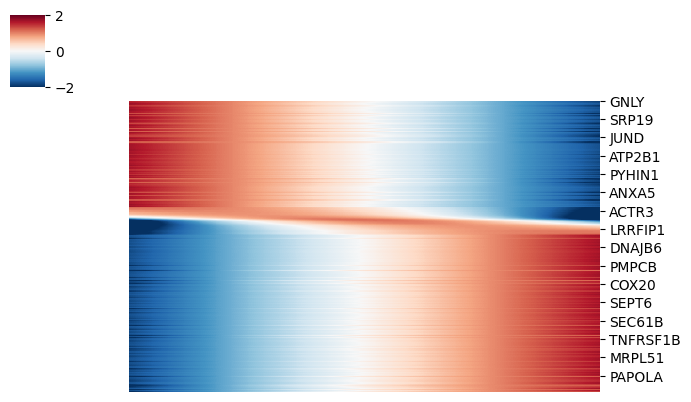

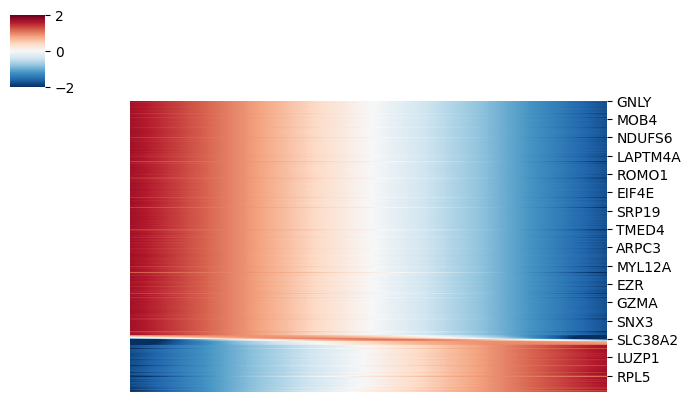

In [38]:
plot_order_path1 = selected_trends_path1.idxmax(axis=1).sort_values().index
sns.clustermap(
    selected_trends_path1.loc[plot_order_path1, :],
    z_score=0,
    cmap="RdBu_r",
    col_cluster=False,
    row_cluster=False,
    vmin=-2,
    vmax=2,
    figsize=[7, 4],
    xticklabels=0,
)
plt.savefig(f"../../pipeline_testing/transitory_cells/{sample}/{archetype}/gene_expression_trends_with_pseudotime_along_path1.pdf", dpi=300)
plt.show()

plot_order_path2 = selected_trends_path2.idxmax(axis=1).sort_values().index
sns.clustermap(
    selected_trends_path2.loc[plot_order_path2, :],
    z_score=0,
    cmap="RdBu_r",
    col_cluster=False,
    row_cluster=False,
    vmin=-2,
    vmax=2,
    figsize=[7, 4],
    xticklabels=0,
)
plt.savefig(f"../../pipeline_testing/transitory_cells/{sample}/{archetype}/gene_expression_trends_with_pseudotime_along_path2.pdf", dpi=300)
plt.show()

# plot_order_path3 = selected_trends_path3.idxmax(axis=1).sort_values().index
# sns.clustermap(
#     selected_trends_path3.loc[plot_order_path3, :],
#     z_score=0,
#     cmap="RdBu_r",
#     col_cluster=False,
#     row_cluster=False,
#     vmin=-2,
#     vmax=2,
#     figsize=[7, 4],
#     xticklabels=0,
# )
# plt.savefig(f"../../pipeline_testing/transitory_cells/{sample}/gene_expression_trends_with_pseudotime_along_path3.pdf", dpi=300)
# plt.show()

# plot_order_path4 = selected_trends_path4.idxmax(axis=1).sort_values().index
# sns.clustermap(
#     selected_trends_path4.loc[plot_order_path4, :],
#     z_score=0,
#     cmap="RdBu_r",
#     col_cluster=False,
#     row_cluster=False,
#     vmin=-2,
#     vmax=2,
#     figsize=[7, 4],
#     xticklabels=0,
# )
# plt.savefig(f"../../pipeline_testing/transitory_cells/{sample}/gene_expression_trends_with_pseudotime_along_path4.pdf", dpi=300)
# plt.show()

In [39]:
from scipy.io import loadmat
parti_data = loadmat(f'../../pipeline_testing/parti_result/{sample}/Variables.mat')
pc_data = pd.DataFrame(parti_data['pc'])
pc_data.index = all_cells.index
pc_data = pc_data.iloc[:,0:3]
pc_data.columns = ['pc1', 'pc2', 'pc3']
pc_data_pseudotime = pc_data.loc[pc_data.index.isin(adata.obs.index),:]

In [40]:
pc_data_pseudotime[['cell_type', 'pseudotime']] = adata.obs[['cell_type', 'palantir_pseudotime']]
pc_data_pseudotime_sorted = pc_data_pseudotime.sort_values(by='pseudotime', ascending=True)

/tmp/ipykernel_39853/547849853.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pc_data_pseudotime[['cell_type', 'pseudotime']] = adata.obs[['cell_type', 'palantir_pseudotime']]
/tmp/ipykernel_39853/547849853.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pc_data_pseudotime[['cell_type', 'pseudotime']] = adata.obs[['cell_type', 'palantir_pseudotime']]


In [41]:
branch_df = adata.obsm['branch_masks']
path1 = branch_df[branch_df['path1']==True]
path2 = branch_df[branch_df['path2']==True]
# path3 = branch_df[branch_df['path3']==True]
# path4 = branch_df[branch_df['path4']==True]

pc_data_pseudotime_sorted_path1 = pc_data_pseudotime_sorted.loc[pc_data_pseudotime_sorted.index.isin(path1.index),:]
pc_data_pseudotime_sorted_path2 = pc_data_pseudotime_sorted.loc[pc_data_pseudotime_sorted.index.isin(path2.index),:]
# pc_data_pseudotime_sorted_path3 = pc_data_pseudotime_sorted.loc[pc_data_pseudotime_sorted.index.isin(path3.index),:]
# pc_data_pseudotime_sorted_path4 = pc_data_pseudotime_sorted.loc[pc_data_pseudotime_sorted.index.isin(path4.index),:]

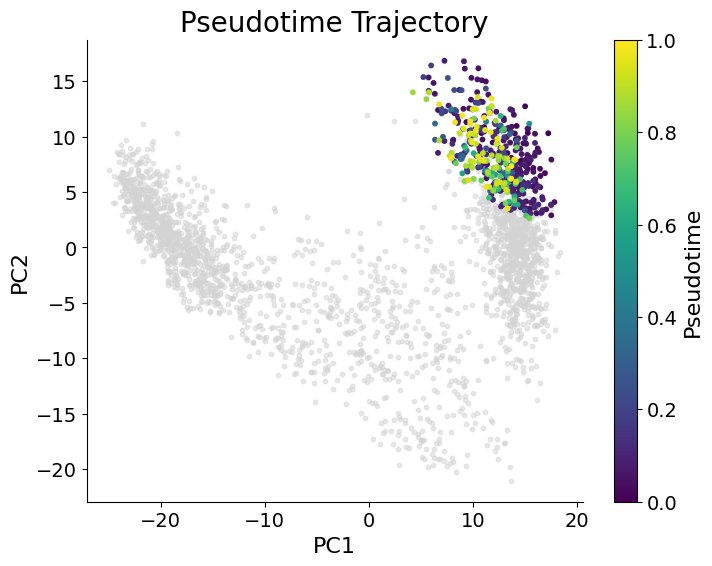

In [42]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
plt.figure(figsize=(8, 6))
plt.scatter(
    pc_data['pc1'], 
    pc_data['pc2'], 
    c='lightgrey',      
    s=10,            
    alpha=0.5,          
    label='All Cells',
    rasterized=True    
)
sc = plt.scatter(
    pc_data_pseudotime_sorted_path1['pc1'],  # Please change line 15-17 accordingly for other paths. This is for path1 only
    pc_data_pseudotime_sorted_path1['pc2'], 
    c = pc_data_pseudotime_sorted_path1['pseudotime'], 
    cmap='viridis',     
    s=10,               
    label='Trajectory Path'
)
cbar = plt.colorbar(sc)
cbar.ax.tick_params(labelsize=14)  
cbar.set_label('Pseudotime', fontsize=16) 
plt.xlabel('PC1', fontsize=16)
plt.ylabel('PC2', fontsize=16)
plt.title('Pseudotime Trajectory', fontsize=20)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.savefig(f'../../pipeline_testing/transitory_cells/{sample}/{archetype}/{archetype}_path1.pdf', dpi=300)
plt.show()

## Archetype based coloring on umap branch points

In [43]:
import anndata as ad
import pandas as pd
import glob
import os
# adata = ad.read_h5ad(f"../../pipeline_testing/transitory_cells/{sample}/{archetype}/adata_{archetype}_palantir_result.h5ad")
umap_data = pd.DataFrame(adata.obsm['X_umap'])
umap_data.columns = ['umap1', 'umap2']
obs_data = adata.obs
umap_data.index = obs_data.index
branch_info = adata.obsm['branch_masks']

## Choose one from 14-17 as per your number of paths. We observed maximum 4 trajectory paths in our analysis

# umap_data[['path1', 'path2', 'path3', 'path4']] = branch_info[['path1', 'path2', 'path3', 'path4']]
# umap_data[['path1', 'path2', 'path3']] = branch_info[['path1', 'path2', 'path3']]
umap_data[['path1', 'path2']] = branch_info[['path1', 'path2']]
# umap_data['path1'] = branch_info['path1']

files = glob.glob(f'../../pipeline_testing/mellon_analysis/{sample}/*_specialists_and_generalists.csv', recursive=True)
files.sort()

sg_cells = []
for file in files:
    df = pd.read_csv(file, index_col=0)
    sg_cells.append(df)

sg_cells_merged = pd.concat(sg_cells, axis=0)
all_cells = pd.read_csv(f"../../pipeline_testing/data/{sample}/{sample}_required_cell_modified.tsv", sep="\t")
trans_cells = all_cells.loc[~all_cells.index.isin(sg_cells_merged.cells),:]

for i, df in enumerate(sg_cells):
    file_name = os.path.basename(files[i])
    # arc_no = "_".join(file_name.split("_")[:2])
    if (file_name.startswith('Archetype')==True): 
        arc_no = file_name.split('_specialists')[0]
    else:
        arc_no = 'generalists'
    
    identifier_string = arc_no
    cells_to_match = df['cells'].dropna().unique()
    valid_matches = umap_data.index.intersection(cells_to_match)
    if not valid_matches.empty:
        umap_data.loc[valid_matches, 'archetype'] = identifier_string

umap_data['archetype'] = umap_data['archetype'].fillna('trans_cells')
match_wp = umap_data.index.intersection(adata.uns['palantir_waypoints'])
umap_data.loc[match_wp, 'waypoints'] = True
umap_data['pseudotime'] = adata.obs.palantir_pseudotime
mapping = all_cells.set_index('index')['Cell_type']
umap_data['cell_type'] = umap_data.index.map(mapping)

In [44]:
np.unique(umap_data['archetype'])

array(['Archetype_4_0', 'Archetype_5', 'trans_cells'], dtype=object)

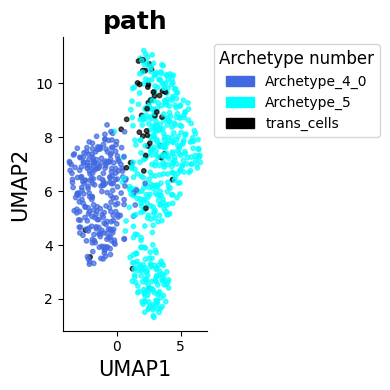

In [46]:
import numpy as np
import matplotlib.pyplot as plt

elements = np.unique(umap_data['archetype'])

color_map = {
    elements[0]: 'royalblue',  
    elements[1]: 'cyan',
    elements[2]: 'black'
}

# color_map = {
#     elements[0]: 'royalblue',  
#     elements[1]: 'cyan',
#     elements[2]: 'olive',
#     elements[3]: 'seagreen',
#     elements[4]: 'purple',
#     # elements[4]: 'peru',
#     elements[5]: 'rosybrown'
# }

colors = umap_data['archetype'].map(color_map)

# plt.figure(figsize=(8, 6))
plt.scatter(umap_data.iloc[:,0],umap_data.iloc[:,1],c=colors,s=10, alpha=0.7)

# Title and labels
plt.title('path', fontsize=18, fontweight='bold')
plt.xlabel('UMAP1', fontsize=15)
plt.ylabel('UMAP2', fontsize=15)

#Customize legend
from matplotlib.patches import Patch
legend_patches = [Patch(color=color_map[key], label=key) for key in color_map]
plt.legend(handles= legend_patches, title = 'Archetype number', title_fontsize='12', fontsize='10', bbox_to_anchor=(1,1))
plt.tight_layout()
plt.savefig(f"../../pipeline_testing/transitory_cells/{sample}/{archetype}/all_traj_together_arch_wise_umap.pdf", dpi=300)
plt.show()

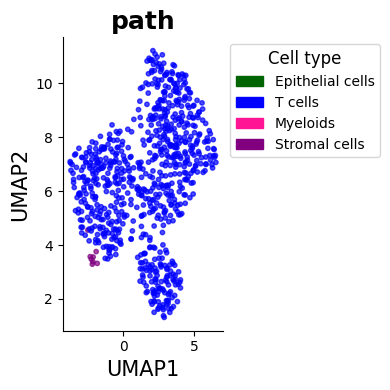

In [47]:
import numpy as np
import matplotlib.pyplot as plt

elements = np.unique(umap_data['cell_type'])

color_map = {
    'Epithelial cells': 'darkgreen',  
    'T cells': 'blue',
    'Myeloids': 'deeppink',
    'Stromal cells': 'purple'
}

colors = umap_data['cell_type'].map(color_map)

# plt.figure(figsize=(8, 6))
plt.scatter(umap_data.iloc[:,0],umap_data.iloc[:,1],c=colors,s=10, alpha=0.7)

# Title and labels
plt.title('path', fontsize=18, fontweight='bold')
plt.xlabel('UMAP1', fontsize=15)
plt.ylabel('UMAP2', fontsize=15)

#Customize legend
from matplotlib.patches import Patch
legend_patches = [Patch(color=color_map[key], label=key) for key in color_map]
plt.legend(handles= legend_patches, title = 'Cell type', title_fontsize='12', fontsize='10', bbox_to_anchor=(1,1))
plt.tight_layout()
plt.savefig(f"../../pipeline_testing/transitory_cells/{sample}/{archetype}/all_traj_together_celltype_umap.pdf", dpi=300)
plt.show()

## Extracting gene names involved in gene change score abalysis from h5ad file

In [49]:
import pandas as pd
gc_score_df = adata.var
path1_gc = pd.DataFrame(gc_score_df['change_scores_path1'])
path1_gc.columns = ['path1_score']

path2_gc = pd.DataFrame(gc_score_df['change_scores_path2'])
path2_gc.columns = ['path2_score']

# path3_gc = pd.DataFrame(gc_score_df['change_scores_path3'])
# path3_gc.columns = ['path3_score']

# path4_gc = pd.DataFrame(gc_score_df['change_scores_path4'])
# path4_gc.columns = ['path4_score']

path1_gc = path1_gc.sort_values(by='path1_score', ascending=False)
path1_gc = path1_gc.head(round(0.05 * path1_gc.shape[0]))
path1_gc.to_csv(f"../../pipeline_testing/transitory_cells/{sample}/{archetype}/genes_path1.csv")

path2_gc = path2_gc.sort_values(by='path2_score', ascending=False)
path2_gc = path2_gc.head(round(0.05 * path2_gc.shape[0]))
path2_gc.to_csv(f"../../pipeline_testing/transitory_cells/{sample}/{archetype}/genes_path2.csv")

# path3_gc = path3_gc.sort_values(by='path3_score', ascending=False)
# path3_gc = path3_gc.head(round(0.05 * path3_gc.shape[0]))
# path3_gc.to_csv(f"../../pipeline_testing/transitory_cells/{sample}/genes_path3.csv")

# path4_gc = path4_gc.sort_values(by='path4_score', ascending=False)
# path4_gc = path4_gc.head(round(0.05 * path4_gc.shape[0]))
# path4_gc.to_csv(f"../../pipeline_testing/transitory_cells/{sample}/genes_path4.csv")

In [50]:
# save the whole ann data object
adata.write_h5ad(f"../../pipeline_testing/transitory_cells/{sample}/{archetype}/adata_A4_0_A5_palantir_result.h5ad", compression="gzip")